In [1]:
import numpy as np
import random
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn as sk
from pathlib import Path

In [2]:
#Let's experimentally determine the threshold by having Bob run the protocol in specific cases.
#This protocol has been modified to have Bob take several (q) individual selections from U.

n = 10000 #size of Bob and Alice's set
k = 16 #size of U
mu = 20000 #mean of distro 
mu2 = 20500
num_trials = 1500
q = 100 #number of times bob selects from U
s_start = 10000
s_end = 1000000

U = np.random.exponential(scale=mu, size = k) #Bob's set. This is also when U is determined for the protocol below.

candidate_list_U = []

#Run protocol several times to get a dataset of E-S/n values.

for i in range(num_trials):
    
    S = random.randint(s_start, s_end) #Bob's random number

    bob_select_list = []
    for j in range (q):
        bobChoice  = random.sample(tuple(U),1)[0] #samples 1 times from U
        bob_select_list.append(bobChoice)

    aliceSum = int(sum(bob_select_list)) + S #combines Bob's samples with his private key to be sent to Alice

    aliceSample = np.random.exponential(scale=mu, size = int(n-q)) #alice fills out the transmission with n-q samples of her distribution

    A = (aliceSum+sum(aliceSample))/n #Alice takes the mean

    E = A - mu #Subtracts the mean of her distribution
    
    threshold_candidate = abs(E - S/n) #This is what Bob computes when he receives E.

    candidate_list_U.append(threshold_candidate) #Adds the result to a list

experimental_threshold_U = np.percentile(candidate_list_U, 80) #This is the threshold value that gives a success rate of 0.8
print(f"The 80th percentile for a threshold where they use U is: {experimental_threshold_U}")

#As a note, running the above with the 30th percentile also retrieves a success rate very close to 1 --> 0.99 approximately 

#We can perform the same computation for distribution 2 if we'd like, and compare.

candidate_list_V = []
bob_select_list=[]
V = np.random.exponential(scale=mu2, size = k) #Bob's set.

for i in range(num_trials):
    
    S = random.randint(s_start,s_end) #Bob's random number

    bob_select_list = []
    for j in range (q):
        bobChoice  = random.sample(tuple(V),1)[0] #samples 1 time from V
        bob_select_list.append(bobChoice)
        
    aliceSum = int(sum(bob_select_list)) + S #combines Bob's samples with his private key to be sent to Alice

    aliceSample = np.random.exponential(scale=mu2, size = int(n-q)) #alice fills out the transmission with n-q samples of her distribution

    A = (aliceSum+sum(aliceSample))/n #Alice takes the mean

    E = A - mu2 #Subtracts the mean of her distribution
    
    threshold_candidate = abs(E - S/n) #This is what Bob computes when he receives E.

    candidate_list_V.append(threshold_candidate) #Adds the result to a list

experimental_threshold_V = np.percentile(candidate_list_V, 80) #This is the threshold value that gives a success rate of 0.8
print(f"The 80th percentile for a threshold where they use V is: {experimental_threshold_V}")



#Now what if Bob and Alice's dstributions don't agree? Let Bob have distro 1 (i.e. U)
#and Alice has distro 2 (i.e. V)

candidate_list_disagree = []
bob_select_list=[]
for i in range(num_trials):
    
    S = random.randint(s_start,s_end) #Bob's random number
    bob_select_list=[0]
    for b in range(q):
        bobChoice  = random.sample(tuple(U),1)[0] #samples 1 time from U
        bob_select_list.append(bobChoice)

    aliceSum = int(sum(bob_select_list)) + S #combines Bob's samples with his private key to be sent to Alice

    aliceSample = np.random.exponential(scale=mu2, size = int(n-q)) #alice fills out the transmission with n-k samples of her distribution

    A = (aliceSum+sum(aliceSample))/n #Alice takes the mean

    E = A - mu2 #Subtracts the mean of her distribution
    
    threshold_candidate = abs(E - S/n) #This is what Bob computes when he receives E.

    candidate_list_disagree.append(threshold_candidate) #Adds the result to a list

experimental_threshold_disagree = np.percentile(candidate_list_disagree, 80) #This is the threshold value that gives a success rate of 0.8
print(f"The 80th percentile for a threshold where they disagree is: {experimental_threshold_disagree}")

print(f"The minimum result for when they disagree was {min(candidate_list_disagree)}")
print(f"The minimum result for when they agree (U) was {min(candidate_list_U)}")
print(f"The maximum result for when they disagree was {max(candidate_list_disagree)}")
print(f"The maximum result for when they agree (U) was {max(candidate_list_U)}")
print(f"The minimum result for when they agree (V) is {min(candidate_list_V)}")
print(f"The maximum result for when they agree (V) is {max(candidate_list_V)}")

The 80th percentile for a threshold where they use U is: 264.2571620727257
The 80th percentile for a threshold where they use V is: 279.3783699963273
The 80th percentile for a threshold where they disagree is: 261.36767687688285
The minimum result for when they disagree was 0.09342126745996637
The minimum result for when they agree (U) was 0.20736317117953007
The maximum result for when they disagree was 643.0920286544454
The maximum result for when they agree (U) was 651.725451650025
The minimum result for when they agree (V) is 0.3244763672902735
The maximum result for when they agree (V) is 680.8280516887858


In [3]:
#This code will have Bob select a single value from the set U q times. A candidate value for q is 100.
#As with the other protocols, we are starting with the exponential distribution.
#Parameter values are:

n = 400000 #Total size of selection of bob and alice combined
k = 16 #Size of set U
q = 100 #Number of selections bob makes from U
mu1 = 20000 #mean of distribution U
mu2 = 20500 #mean of distribution V
S_start = 10000 #Lower bound of bob's range for private key
S_end = 1000000 #Upper bound of bob's range for private key
num_trials = 1500 #Number of times experiment is run

In [4]:
#The protocol is now run where Bob selects 100 individual values from U.
success_rate = 0
failure_rate = 0
inconclusive_rate = 0

selection_sums = []
alice_selection_sums = []
for i in range(num_trials): #run the whole protocol a specified number of times
    
    bob_selection = []
    for i in range(q): # create bob's selection list
        selection = random.choice(tuple(U))
        bob_selection.append(selection)

    selection_sums.append(sum(bob_selection)) # Create list of the values of Bob's sum.
    
    S = random.randint(S_start, S_end) #Bob's private key

    bob_transmission = sum(bob_selection) + S #This is sent to Alice

    alice_choice = random.choice(["U", "V"])

    if alice_choice == "U":
        alice_addition = np.random.exponential(scale=mu1, size=n-q)
        total_sum = sum(alice_addition) + bob_transmission
        A = total_sum/n
        E = total_sum - mu1
    elif alice_choice == "V":
        alice_addition = np.random.exponential(scale=mu2, size=n-q)
        total_sum = sum(alice_addition) + bob_transmission
        A = total_sum/n
        E = A - mu2
        
    alice_selection_sums.append(sum(alice_addition)) #This is to track the value of Alice's selection
    
    #This is sent back to Bob. 

    bob_value = abs(E - S/n)

    if bob_value > experimental_threshold_U:
        bob_guess = "U"
    else:
        bob_guess = "V"

    if (alice_choice == bob_guess):
        success_rate += 1
    elif alice_choice != bob_guess:
        failure_rate += 1
    else:
        inconclusive_rate += 1
        
print(f"The experimental threshold is: {experimental_threshold_U}")
print(f"The success rate is: {success_rate/num_trials}")
print(f"The failure rate is: {failure_rate/num_trials}")
print(f"The inconclusive rate is: {inconclusive_rate/num_trials}")

print(success_rate/num_trials + failure_rate/num_trials + inconclusive_rate/num_trials)
print("Bob's selection diagnostics:")
print(f"Average value of his sum: {sum(selection_sums)/num_trials}")
print(f"Min value of his sum: {min(selection_sums)}")
print(f"Max value of his sum: {max(selection_sums)}")
print("Alice's selection diagnostics:")
print(f"Average value of her addition: {sum(alice_selection_sums)/num_trials}")
print(f"Ratio of Bob's signal sans his private key to alice's addition: {(sum(selection_sums)/num_trials)/(sum(alice_selection_sums)/num_trials)}")

The experimental threshold is: 264.2571620727257
The success rate is: 1.0
The failure rate is: 0.0
The inconclusive rate is: 0.0
1.0
Bob's selection diagnostics:
Average value of his sum: 1916184.4255438251
Min value of his sum: 1365020.6879046531
Max value of his sum: 2471119.5496392604
Alice's selection diagnostics:
Average value of her addition: 8099079455.082742
Ratio of Bob's signal sans his private key to alice's addition: 0.00023659286665489925


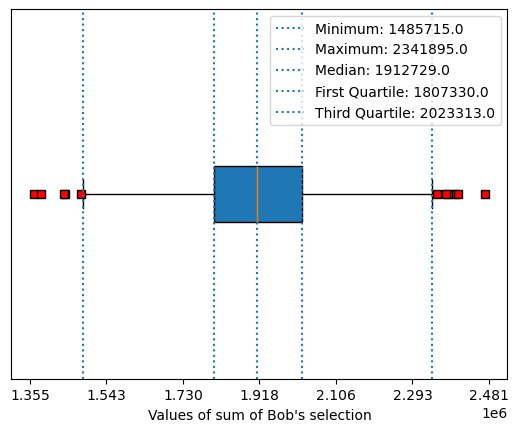

There are 11 fliers


In [5]:
Q1 = np.percentile(selection_sums, 25)
Q3 = np.percentile(selection_sums, 75)
IQR = Q3 - Q1

#Define non-outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Filter data and find the boundaries
non_outliers = []
outlier_count = 0
for i in range(len(selection_sums)):
    if (selection_sums[i] >= lower_bound) and (selection_sums[i]<= upper_bound):
        non_outliers.append(selection_sums[i])
    else:
        outlier_count += 1

plt.boxplot(selection_sums, vert=False, patch_artist=True, flierprops=dict(marker='s', markerfacecolor='red'))
plt.axvline(min(non_outliers), linestyle=":", label = f"Minimum: {round(min(non_outliers),0)}")
plt.axvline(max(non_outliers), linestyle=":", label = f"Maximum: {round(max(non_outliers),0)}")
plt.axvline(np.percentile(non_outliers,50), linestyle=":", label = f"Median: {round(np.percentile(non_outliers,50),0)}")
plt.axvline(Q1, linestyle=":", label = f"First Quartile: {round(Q1,0)}")
plt.axvline(Q3, linestyle=":", label = f"Third Quartile: {round(Q3,0)}")
plt.xlabel("Values of sum of Bob's selection")
plt.yticks([])
plt.xticks(np.round(np.linspace(min(selection_sums)-10000, max(selection_sums)+10000, 7),0))
plt.legend()
plt.show()
print(f"There are {outlier_count} fliers")
#This goes through some preprocessing - taking out outliers (which are minimal)